In [1]:
import pandas as pd
import numpy as np

In [5]:
file_path = r"C:\Users\rahul\Downloads\Ecommerce_Customer_Journey_1000.xlsx"
loyalty_df = pd.read_excel(file_path, sheet_name="7.3 Loyalty-Repurchase")

In [6]:
loyalty_df.head()

,loyalty_id,points_earned,points_redeemed,tier,repeat_purchase_flag,days_since_last_order,LTV,churn_risk_score
0,LOY000001,8906,1228,Bronze,N,129,77090.93,1.00
1,LOY000002,3533,2259,Silver,N,143,171228.46,0.23
2,LOY000003,6044,639,Gold,N,371,99921.32,0.79
3,LOY000004,8228,2324,Bronze,N,391,201445.67,0.91
4,LOY000005,2482,1534,Silver,Y,39,85256.01,0.28


In [7]:
numeric_df = loyalty_df.select_dtypes(include=["number"]) #keeping only the continous variable.

In [8]:
numeric_df.head()

,points_earned,points_redeemed,days_since_last_order,LTV,churn_risk_score
0,8906,1228,129,77090.93,1.00
1,3533,2259,143,171228.46,0.23
2,6044,639,371,99921.32,0.79
3,8228,2324,391,201445.67,0.91
4,2482,1534,39,85256.01,0.28


In [12]:
#Steps to import the sklearn and tandardizes all numeric feature.
import sklearn  
from sklearn.cluster import KMeans  
from sklearn.preprocessing import StandardScaler                                                     
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

AttributeError: 'numpy.ndarray' object has no attribute 'head'

C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Window

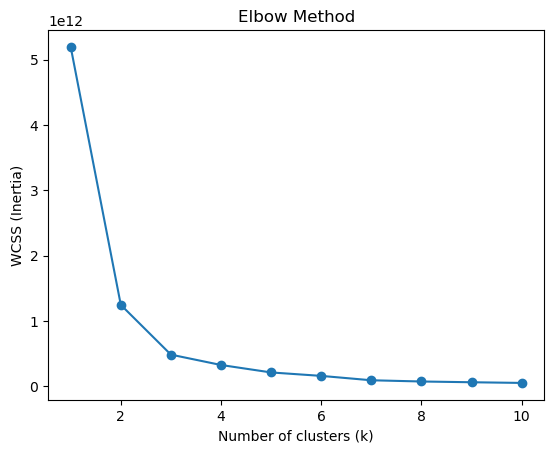

In [21]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):   # loop should match the plot range
    km = KMeans(n_clusters=k, random_state=304).fit(numeric_df)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.show()


C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Window

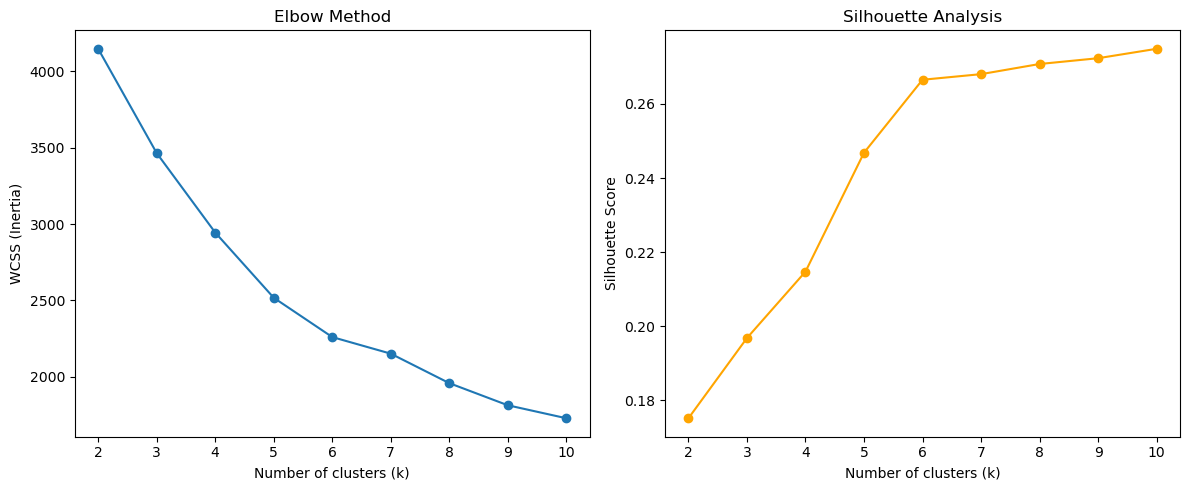

In [24]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use scaled data for clustering
wcss = []
silhouette_scores = []

for k in range(2, 11):   # silhouette is undefined for k=1
    km = KMeans(n_clusters=k, random_state=304).fit(scaled_data)
    wcss.append(km.inertia_)
    score = silhouette_score(scaled_data, km.labels_)
    silhouette_scores.append(score)

# Plot elbow (WCSS)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(2, 11), wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")

# Plot silhouette scores
plt.subplot(1,2,2)
plt.plot(range(2, 11), silhouette_scores, marker="o", color="orange")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.tight_layout()
plt.show()


In [25]:
clust = KMeans(n_clusters = 3, random_state = 304 ) 

In [29]:
labels = clust.fit_predict(scaled_data)

C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [30]:
labels

array([0, 1, 2, 0, 2, 0, 1, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 1, 2, 1,
       0, 0, 2, 1, 2, 1, 1, 1, 2, 0, 2, 0, 1, 2, 2, 0, 1, 0, 2, 2, 2, 1,
       2, 1, 1, 1, 0, 1, 1, 2, 1, 0, 2, 2, 0, 2, 1, 0, 0, 1, 2, 2, 2, 0,
       1, 2, 2, 0, 0, 1, 1, 0, 1, 0, 1, 2, 2, 0, 0, 1, 2, 2, 0, 2, 2, 1,
       0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 1, 2, 2, 2, 0, 1, 1, 2, 2, 0, 2, 0,
       1, 2, 0, 1, 1, 2, 2, 2, 2, 1, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0,
       0, 2, 0, 1, 2, 2, 1, 2, 2, 0, 0, 2, 1, 2, 2, 2, 2, 2, 0, 1, 2, 1,
       1, 2, 2, 2, 1, 2, 2, 1, 2, 0, 2, 2, 2, 0, 2, 1, 0, 2, 1, 2, 2, 1,
       0, 0, 0, 1, 1, 1, 2, 2, 2, 0, 0, 0, 1, 2, 1, 0, 0, 1, 2, 1, 0, 2,
       2, 2, 2, 1, 0, 0, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 1, 0, 0, 2, 2, 2,
       1, 1, 0, 1, 2, 0, 2, 1, 2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 1, 1, 1, 1,
       1, 2, 2, 2, 0, 0, 2, 0, 2, 1, 0, 1, 1, 1, 2, 2, 1, 2, 2, 1, 2, 2,
       2, 1, 2, 2, 0, 2, 2, 0, 2, 1, 0, 1, 1, 2, 2, 1, 1, 2, 1, 0, 1, 2,
       2, 1, 0, 2, 2, 2, 0, 2, 2, 2, 1, 2, 0, 0, 2,

In [31]:
clust.cluster_centers_  ##Centroid cluster

array([[ 0.77411576, -0.68528322, -0.23138413,  1.04238842,  0.40214896],
       [-0.80854734,  1.04505893, -0.23914911,  0.27673321, -0.11620462],
       [ 0.02807558, -0.22755334,  0.2875826 , -0.80272698, -0.17243997]])

In [32]:
pd.crosstab (index=labels,columns="count")

col_0,count
row_0,
0,273
1,277
2,450


In [34]:
t = pd.crosstab(loyalty_df["tier"], labels)
print(t)

col_0      0   1    2
tier                 
Bronze    64  80  125
Gold      55  32   83
Platinum  55  68  113
Silver    99  97  129


In [35]:
t_percent = pd.crosstab(loyalty_df["tier"], labels, normalize="index") * 100
print(t_percent.round(2))

col_0         0      1      2
tier                         
Bronze    23.79  29.74  46.47
Gold      32.35  18.82  48.82
Platinum  23.31  28.81  47.88
Silver    30.46  29.85  39.69


In [36]:
t1 = pd.crosstab(loyalty_df["repeat_purchase_flag"], labels)
print(t1)

col_0                   0    1    2
repeat_purchase_flag               
N                     122  204  213
Y                     151   73  237


In [37]:
t1_percent = pd.crosstab(loyalty_df["repeat_purchase_flag"], labels, normalize="index") * 100
print(t1_percent.round(2))

col_0                     0      1      2
repeat_purchase_flag                     
N                     22.63  37.85  39.52
Y                     32.75  15.84  51.41


In [38]:
import scipy
from scipy import stats

In [39]:
stats.chi2_contingency(t1)   

Chi2ContingencyResult(statistic=np.float64(60.59833494243362), pvalue=np.float64(6.938071337939222e-14), dof=2, expected_freq=array([[147.147, 149.303, 242.55 ],
       [125.853, 127.697, 207.45 ]]))

#### Interpretation

1.Chi‑square statistic (≈ 60.6) → Very large, showing strong deviation between observed and expected counts.

2.p‑value ≈ 6.9 × 10⁻¹⁴ → Extremely small, far below 0.05. This means the association is highly statistically significant.

3.Degrees of freedom (dof = 2) → With 2 categories (repeat vs non‑repeat) and 3 clusters, you get (2‑1) × (3‑1) = 2.

4.Expected frequencies → The counts I would expect if repeat purchase and cluster assignment were independent. Mine observed counts differ substantially.

In [40]:
stats.chi2_contingency(t)   

Chi2ContingencyResult(statistic=np.float64(14.409079462881301), pvalue=np.float64(0.02538580102203678), dof=6, expected_freq=array([[ 73.437,  74.513, 121.05 ],
       [ 46.41 ,  47.09 ,  76.5  ],
       [ 64.428,  65.372, 106.2  ],
       [ 88.725,  90.025, 146.25 ]]))

#### Interpretation

1.Chi‑square statistic (≈ 14.41) → Measures how far the observed counts deviate from the expected counts under independence. A higher value means stronger deviation.

2.p‑value (≈ 0.025) → Since this is below 0.05, I reject the null hypothesis of independence. That means tier and cluster are significantly associated.

3.Degrees of freedom (dof = 6) → Comes from (rows‑1) × (columns‑1). You had 4 tiers × 3 clusters.

4.Expected frequencies → The counts I would expect if tier and cluster were unrelated. Mine observed counts differ enough to trigger significance.